In [ ]:
import pandas as pd
import numpy as np

# Merge microbiome and metabolome risk scores
MetRS_df = pd.read_csv('/path/to/input/Metabo_score_weighted_sum.tsv', sep='\t')
MRS_df = pd.read_csv('/path/to/input/MRS_all_z.txt', sep='\t')
PRS_df = pd.read_csv('/path/to/input/PRS_all_z.tsv', sep='\t')

prs_cols = ['SampleID', 'PGS002361_cvd_z']
PRS_df = PRS_df[prs_cols]

merged_score_df = pd.merge(MetRS_df, MRS_df, on='SampleID', how='inner')
merged_score_df = pd.merge(merged_score_df, PRS_df, on='SampleID', how='inner')

z_cols = [c for c in merged_score_df.columns if c.endswith('_z')]
merged_score_df_z = merged_score_df[['SampleID', 'Group'] + z_cols].copy()

metadata = pd.read_csv('/path/to/input/metadata.tsv', sep='\t')
# display(metadata)

conventional_risk_factors = [
    'SampleID', 'Group',
    'age',
    'sex',
    'Hypertension',
    'Diabetes',
    'Tg',
    'LDL',
    'smoking',
    'drinking',
]

metadata_parsed = metadata.copy()
metadata_parsed = metadata_parsed[conventional_risk_factors]

sex_mapping = {'M': 1, 'F': 0, 'Male': 1, 'Female': 0}
metadata_parsed['sex'] = metadata_parsed['sex'].map(sex_mapping)

# display(metadata_parsed)

merged_all = metadata_parsed.merge(merged_score_df_z, on=['SampleID', 'Group'], how='inner')
display(merged_all)
merged_all.to_csv('/path/to/output/merged_scores.tsv', sep='\t', index=False)

,SampleID,Group,age,sex,Hypertension,Diabetes,Tg,LDL,smoking,drinking,MetRS_z,aMRS_z,paMRS_z,PGS002361_cvd_z
0,M001,SA,49,1,1,0,83.0,45.0,1,1,-0.916790,-0.585393,-0.588606,-0.424448
1,M002,ACS,89,1,0,1,65.0,37.0,1,1,0.259489,0.466571,-0.628033,0.547242
2,M003,SA,84,0,1,0,271.0,77.0,0,0,-0.337403,-0.665833,0.042878,-0.759889
3,M004,HFrEF,84,1,0,0,50.0,45.0,0,0,1.244493,-0.993826,1.766283,-0.647332
4,M005,SA,51,1,1,1,61.0,72.0,1,0,-1.252441,0.424554,-0.957705,-0.838375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,M176,SA,71,1,0,1,264.0,99.0,1,0,-0.535009,2.111409,-1.089514,-0.030942
165,M177,HFrEF,45,0,1,0,222.0,93.0,1,0,0.489910,-0.659597,0.756784,2.034089
166,M178,HFrEF,74,0,0,0,NaN,NaN,0,0,1.501078,-0.919198,0.420893,-0.659048
167,M179,HFrEF,80,1,0,0,107.0,52.0,1,0,0.611243,1.098740,0.510468,1.251757


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
import warnings

# 1. Environment setup and warning suppression
warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'sans-serif'

# ------------------------------------------------------------------------------
# [Helper Functions]
# ------------------------------------------------------------------------------

def get_model_results(data, predictors, target='Group_ord', n_splits=5, n_boot=1000):
    """Train model, perform CV predictions, calculate Bootstrap AUC/CI, and evaluate AIC."""
    # Remove missing values
    subset = data[predictors + [target]].dropna().reset_index(drop=True)
    if len(subset) == 0: return None
    
    X, y = subset[predictors], subset[target]
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    y_probs = np.zeros((len(y), 3)) 
    
    aics = [] # Container for AIC values
    
    for train_idx, val_idx in skf.split(X, y):
        try:
            # Fit Ordinal Logit model
            mod = OrderedModel(y.iloc[train_idx], X.iloc[train_idx], distr='logit')
            res = mod.fit(method='bfgs', disp=False, maxiter=500)
            y_probs[val_idx, :] = res.predict(X.iloc[val_idx]).values
            aics.append(res.aic) # Collect AIC for each fold
        except:
            return None

    # Prepare results for each scenario
    y_t1, y_s1 = (y > 0).astype(int), y_probs[:, 1:].sum(axis=1) # S1: Control vs MI+HF
    y_t2, y_s2 = (y > 1).astype(int), y_probs[:, 2]            # S2: (Control+MI) vs HF

    def bootstrap_auc(y_true, y_score):
        boot_aucs = []
        rng = np.random.RandomState(42)
        for _ in range(n_boot):
            idx = rng.randint(0, len(y_true), len(y_true))
            if len(np.unique(y_true[idx])) < 2: continue
            boot_aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
        sorted_aucs = np.sort(boot_aucs)
        return np.mean(boot_aucs), sorted_aucs[int(0.025*n_boot)], sorted_aucs[int(0.975*n_boot)]

    a1, l1, h1 = bootstrap_auc(y_t1, y_s1)
    a2, l2, h2 = bootstrap_auc(y_t2, y_s2)

    return {
        'aic_mean': np.mean(aics), 
        'aic_std': np.std(aics),
        'y_true': {'0_vs_12': y_t1, '01_vs_2': y_t2},
        'y_score': {'0_vs_12': y_s1, '01_vs_2': y_s2},
        '0_vs_12': {'auc': a1, 'ci_low': l1, 'ci_high': h1},
        '01_vs_2': {'auc': a2, 'ci_low': l2, 'ci_high': h2}
    }

def plot_custom_roc(results_dict, title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    scenarios = [('0_vs_12', 'SA vs (ACS + HFrEF)'), 
                 ('01_vs_2', '(SA + ACS) vs HFrEF')]
    colors = plt.cm.Set1(np.linspace(0, 1, len(results_dict)))

    for i, (s_key, s_title) in enumerate(scenarios):
        ax = axes[i]
        for (m_name, res), color in zip(results_dict.items(), colors):
            fpr, tpr, _ = roc_curve(res['y_true'][s_key], res['y_score'][s_key])
            d = res[s_key]
            label = f"{m_name}\nAUC: {d['auc']:.3f} [{d['ci_low']:.3f}-{d['ci_high']:.3f}]"
            ax.plot(fpr, tpr, color=color, lw=2.5, label=label)
        
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, lw=1)
        ax.set_title(s_title, fontweight='bold', fontsize=14)
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.legend(loc='lower right', fontsize=8.5, frameon=True)
        ax.grid(alpha=0.2, linestyle='--')
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig


📊 [Step 1: Omics Pure Models]


,Model Name,CV AIC (Mean±SD),SA vs (ACS + HFrEF) AUC [95% CI],(SA + ACS) vs HFrEF AUC [95% CI]
0,CRFs Only,253.26 ± 2.04,0.584 [0.488-0.674],0.427 [0.317-0.532]
1,MetRS Only,253.74 ± 7.06,0.755 [0.674-0.830],0.824 [0.761-0.884]
2,MRS Only: Both_MRS,268.07 ± 3.18,0.726 [0.643-0.803],0.777 [0.702-0.849]
3,MRS Only: paMRS_z,280.82 ± 2.53,0.682 [0.601-0.762],0.730 [0.646-0.805]
4,PRS Only: PGS002361_cvd_z,296.60 ± 0.96,0.591 [0.499-0.680],0.492 [0.399-0.586]
5,MRS Only: aMRS_z,297.03 ± 2.87,0.591 [0.497-0.683],0.558 [0.459-0.648]


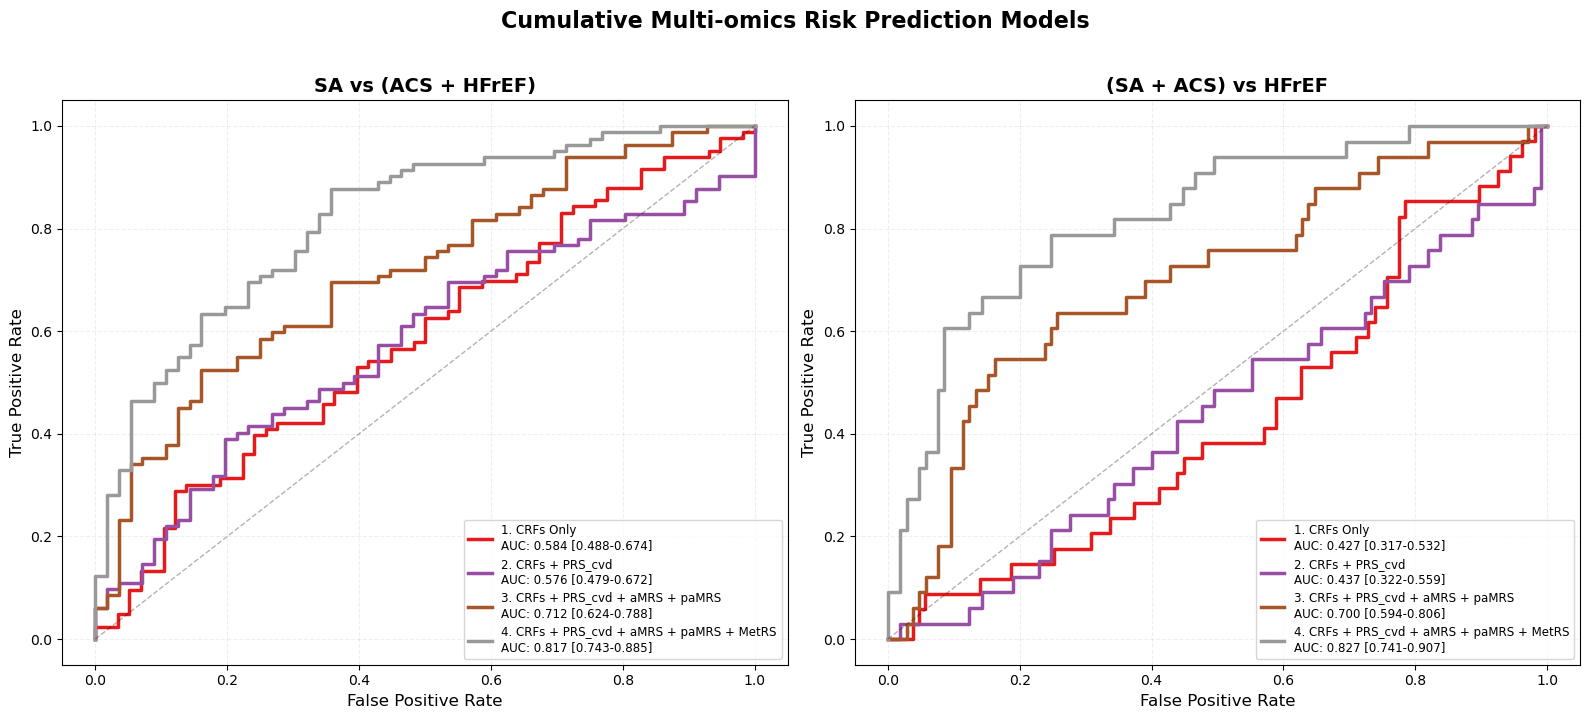


📊 [Step 2: Cumulative Models]


,Cumulative Model,CV AIC (Mean±SD),SA vs (ACS + HFrEF) AUC [95% CI],(SA + ACS) vs HFrEF AUC [95% CI]
0,1. CRFs Only,253.26 ± 2.04,0.584 [0.488-0.674],0.427 [0.317-0.532]
1,2. CRFs + PRS_cvd,247.81 ± 4.08,0.576 [0.479-0.672],0.437 [0.322-0.559]
2,3. CRFs + PRS_cvd + aMRS + paMRS,227.22 ± 4.73,0.712 [0.624-0.788],0.700 [0.594-0.806]
3,4. CRFs + PRS_cvd + aMRS + paMRS + MetRS,194.82 ± 8.39,0.817 [0.743-0.885],0.827 [0.741-0.907]


In [ ]:
import os
df_raw = pd.read_csv('/path/to/input/merged_scores.tsv', sep='\t')
target_map = {'SA': 0, 'ACS': 1, 'HFrEF': 2}
df = df_raw[df_raw['Group'].isin(target_map.keys())].copy()
df['Group_ord'] = df['Group'].map(target_map).astype(int)

cat_cols = ['smoking', 'drinking']
existing_cat = [c for c in cat_cols if c in df.columns]
df = pd.get_dummies(df, columns=existing_cat, drop_first=True)

bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

base_vars = ['age', 'sex', 'Hypertension', 'Diabetes', 'Tg', 'LDL', 'smoking', 'drinking']
crfs = [c for c in base_vars if c in df.columns]

prs_scores = [c for c in df.columns if c.startswith('PGS') and c.endswith('_z')]
metrs_z = 'MetRS_z'

step1_results = {}

step1_results["CRFs Only"] = {'vars': crfs, 'res': get_model_results(df, crfs)}

for prs in prs_scores:
    step1_results[f"PRS Only: {prs}"] = {'vars': [prs], 'res': get_model_results(df, [prs])}

mrs_combos = [(['aMRS_z'], 'aMRS_z'), (['paMRS_z'], 'paMRS_z'), (['aMRS_z', 'paMRS_z'], 'Both_MRS')]
for m_vars, m_label in mrs_combos:
    step1_results[f"MRS Only: {m_label}"] = {'vars': m_vars, 'res': get_model_results(df, m_vars)}

step1_results["MetRS Only"] = {'vars': [metrs_z], 'res': get_model_results(df, [metrs_z])}

s1_summary = []
for name, data in step1_results.items():
    if data['res'] is None: continue
    res = data['res']
    s1_summary.append({
        'Model Name': name,
        'CV AIC (Mean±SD)': f"{res['aic_mean']:.2f} ± {res['aic_std']:.2f}",
        'aic_val': res['aic_mean'],
        'SA vs (ACS + HFrEF) AUC [95% CI]': f"{res['0_vs_12']['auc']:.3f} [{res['0_vs_12']['ci_low']:.3f}-{res['0_vs_12']['ci_high']:.3f}]",
        '(SA + ACS) vs HFrEF AUC [95% CI]': f"{res['01_vs_2']['auc']:.3f} [{res['01_vs_2']['ci_low']:.3f}-{res['01_vs_2']['ci_high']:.3f}]"
    })

df_step1 = pd.DataFrame(s1_summary)

prs_df = df_step1[df_step1['Model Name'].str.contains("PRS Only")]
best_prs_name = prs_df.sort_values('aic_val', ascending=True).iloc[0]['Model Name']
best_prs_vars = step1_results[best_prs_name]['vars']

mrs_df = df_step1[df_step1['Model Name'].str.contains("MRS Only")]
best_mrs_name = mrs_df.sort_values('aic_val', ascending=True).iloc[0]['Model Name']
best_mrs_vars = step1_results[best_mrs_name]['vars']

print("\n📊 [Step 1: Pure Omics Models]")
df_step1_out = df_step1.sort_values('aic_val', ascending=True).drop(columns=['aic_val']).reset_index(drop=True)
display(df_step1_out)
os.makedirs('/path/to/output/results', exist_ok=True)
df_step1_out.to_csv('/path/to/output/results/step1_summary.tsv', sep='\t', index=False)

step2_results_dict = {}

step2_results_dict["1. CRFs Only"] = step1_results["CRFs Only"]['res']

m2_vars = crfs + best_prs_vars
res_m2 = get_model_results(df, m2_vars)
if res_m2: step2_results_dict["2. CRFs + PRS_cvd"] = res_m2

m3_vars = m2_vars + best_mrs_vars
res_m3 = get_model_results(df, m3_vars)
if res_m3: step2_results_dict["3. CRFs + PRS_cvd + aMRS + paMRS"] = res_m3

m4_vars = m3_vars + [metrs_z]
res_m4 = get_model_results(df, m4_vars)
if res_m4: step2_results_dict["4. CRFs + PRS_cvd + aMRS + paMRS + MetRS"] = res_m4

os.makedirs('/path/to/output/plot', exist_ok=True)
plot_custom_roc(step2_results_dict, "Cumulative Multi-omics Risk Prediction Models")
plt.savefig('/path/to/output/plot/roc_curve.png', dpi=300, bbox_inches='tight')
plt.savefig('/path/to/output/plot/roc_curve.pdf', bbox_inches='tight')

plt.show()

step2_summary = []
for name, res in step2_results_dict.items():
    step2_summary.append({
        'Cumulative Model': name,
        'CV AIC (Mean±SD)': f"{res['aic_mean']:.2f} ± {res['aic_std']:.2f}",
        'SA vs (ACS + HFrEF) AUC [95% CI]': f"{res['0_vs_12']['auc']:.3f} [{res['0_vs_12']['ci_low']:.3f}-{res['0_vs_12']['ci_high']:.3f}]",
        '(SA + ACS) vs HFrEF AUC [95% CI]': f"{res['01_vs_2']['auc']:.3f} [{res['01_vs_2']['ci_low']:.3f}-{res['01_vs_2']['ci_high']:.3f}]"
    })

print("\n📊 [Step 2: Cumulative Models]")
df_step2_out = pd.DataFrame(step2_summary)
display(df_step2_out)
df_step2_out.to_csv('/path/to/output/results/step2_summary.tsv', sep='\t', index=False)